### Kaggle Competition: Linking Writing Processes to Writing Quality -                                                                       https://www.kaggle.com/competitions/linking-writing-processes-to-writing-quality/overview

### Configuration

In [ ]:
%pip install ydata-profiling
%pip install ipywidgets ydata-profiling

/Users/patrykksiazek/.zshenv:.:1: no such file or directory: /Users/patrykksiazek/.cargo/env

[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
/Users/patrykksiazek/.zshenv:.:1: no such file or directory: /Users/patrykksiazek/.cargo/env

[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import pandas as pd
import numpy as np
from ydata_profiling import ProfileReport
import matplotlib.pyplot as plt

%matplotlib inline

### Data Loading

In [ ]:
df = pd.read_csv('train_logs.csv')
test_df = pd.read_csv('test_logs.csv')
df_scores = pd.read_csv('train_scores.csv')
sample_submission = pd.read_csv('sample_submission.csv')

### Preliminary Data Analysis

### Data Size

* Number of sources (files, tables)
* Number of records (rows)
* Number of features (columns)
* Does the number match expectations?

In [ ]:
df.shape

(8405898, 11)

In [ ]:
test_df.shape

(6, 11)

In [ ]:
df_scores.shape

(2471, 2)

In [ ]:
sample_submission.shape

(3, 2)

In [ ]:
sample_submission

,id,score
0,0000aaaa,1.0
1,2222bbbb,2.0
2,4444cccc,3.0


In [ ]:
test_df

,id,event_id,down_time,up_time,action_time,activity,down_event,up_event,text_change,cursor_position,word_count
0,0000aaaa,1,338433,338518,85,Input,Space,Space,,0,0
1,0000aaaa,2,760073,760160,87,Input,Space,Space,,1,0
2,2222bbbb,1,711956,712023,67,Input,q,q,q,0,1
3,2222bbbb,2,290502,290548,46,Input,q,q,q,1,1
4,4444cccc,1,635547,635641,94,Input,Space,Space,,0,0
5,4444cccc,2,184996,185052,56,Input,q,q,q,1,1


### Manual Review of Examples - Checking Different Sortings

In [ ]:
df.head()

,id,event_id,down_time,up_time,action_time,activity,down_event,up_event,text_change,cursor_position,word_count
0,001519c8,1,4526,4557,31,Nonproduction,Leftclick,Leftclick,NoChange,0,0
1,001519c8,2,4558,4962,404,Nonproduction,Leftclick,Leftclick,NoChange,0,0
2,001519c8,3,106571,106571,0,Nonproduction,Shift,Shift,NoChange,0,0
3,001519c8,4,106686,106777,91,Input,q,q,q,1,1
4,001519c8,5,107196,107323,127,Input,q,q,q,2,1


In [ ]:
df.tail()

,id,event_id,down_time,up_time,action_time,activity,down_event,up_event,text_change,cursor_position,word_count
8405893,fff05981,3615,2063944,2064440,496,Nonproduction,Leftclick,Leftclick,NoChange,1031,240
8405894,fff05981,3616,2064497,2064497,0,Nonproduction,Shift,Shift,NoChange,1031,240
8405895,fff05981,3617,2064657,2064765,108,Replace,q,q,q => q,1031,240
8405896,fff05981,3618,2069186,2069259,73,Nonproduction,Leftclick,Leftclick,NoChange,1028,240
8405897,fff05981,3619,2070065,2070133,68,Input,.,.,.,1029,240


### Checking Types

* Numeric columns
* Boolean columns
* Categorical columns
* Text columns
* Consistency in missing value indicators: NULL / empty string

In [ ]:
profile = ProfileReport(df, title="Profiling Report")

In [ ]:
%%time 
profile

CPU times: user 3 μs, sys: 1e+03 ns, total: 4 μs
Wall time: 15 μs


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

IOStream.flush timed out
100%|██████████| 11/11 [00:29<00:00,  2.72s/it]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

### Unique Keys

In [ ]:
n_id = len(df['id'].unique())

In [ ]:
n_id

2471

In [ ]:
df.duplicated(subset=['id', 'event_id']).sum()

np.int64(0)

### Missing Values

Percentage of missing values in each column
Getting rid of them:

* Determining the causes, attempting to obtain them
* Filling in based on other sources
* Filling in using average values
* Removing rows
* Removing columns that have, e.g., over 50% missing values

In [ ]:
rows_with_null = df[df.isnull().any(axis=1)]

In [ ]:
rows_with_null

,id,event_id,down_time,up_time,action_time,activity,down_event,up_event,text_change,cursor_position,word_count


### Duplicates

* Repeated keys (IDs)
* Repeated rows -- CHECKED IN REPORT / No Duplicates 
* Unstructured data (embeddings)

### Examining the Distribution of Feature Values

* Range of values
* Distributions
* Plausibility, e.g.: whether height is within realistic ranges
* Basic statistical parameters (mean, median, percentiles, variance)
* Fat tails
* Additional issues:
    * Constant values in a column
    * Excessive cardinality of categorical values 

### ID - Unique Essay Number
* 2471 values
* 8-Character Strings

### Event ID - Chronological mouse and keyboard operations


In [ ]:
max_event_id = df.groupby('id')['event_id'].max().reset_index()

In [ ]:
max_event_id

,id,event_id
0,001519c8,2557
1,0022f953,2454
2,0042269b,4136
3,0059420b,1556
4,0075873a,2531
...,...,...
2466,ffb8c745,4739
2467,ffbef7e5,2604
2468,ffccd6fd,3063
2469,ffec5b38,3242


In [ ]:
max_event_id.describe()

,event_id
count,2471.000000
mean,3401.820316
std,1578.850387
min,262.000000
25%,2193.500000
50%,3082.000000
75%,4301.000000
max,12876.000000


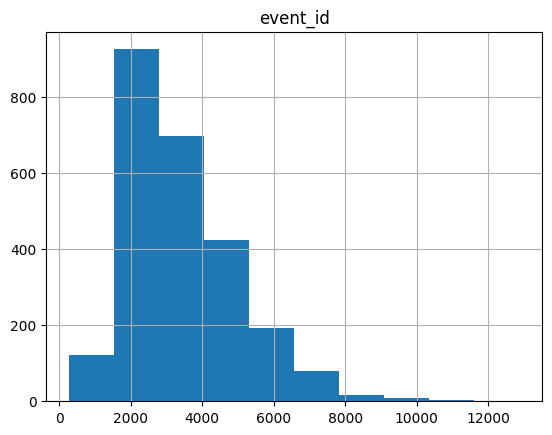

In [ ]:
max_event_id.hist(column='event_id')
plt.show()

### Down Time - time the key or mouse button was pressed (in milliseconds)

### Up Time - time the action ended

### Action Time - duration of the operation 

In [ ]:
sorted_action_time = np.sort(df['action_time'])
len_sorted = len(sorted_action_time)

In [ ]:
perc_values = range(100)

In [ ]:
percentiles = [np.percentile(sorted_action_time, i) for i in perc_values]

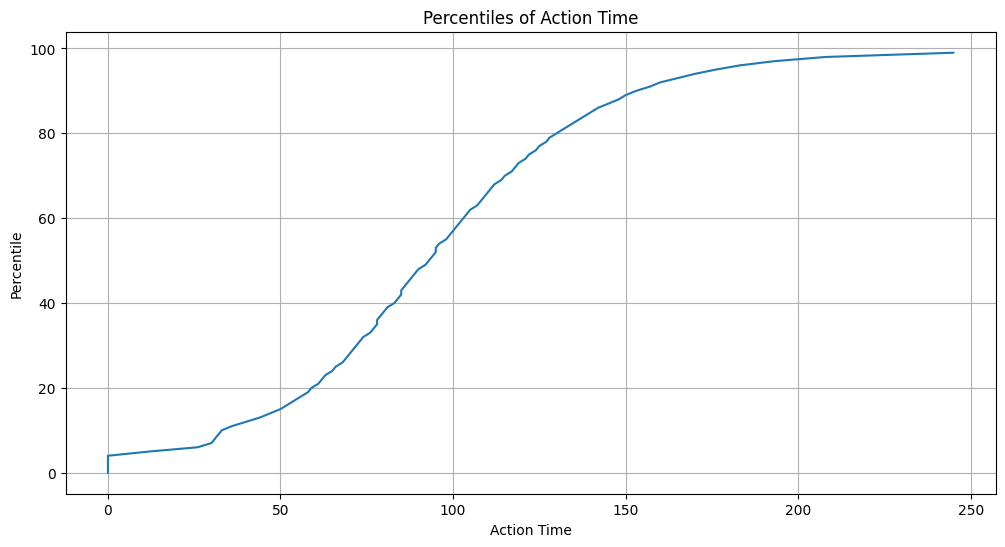

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(percentiles, perc_values)
plt.xlabel('Action Time')
plt.ylabel('Percentile')
plt.title('Percentiles of Action Time')
plt.grid(True)
plt.show()

### Activity - type of change

In [ ]:
df['activity'].value_counts()

activity
Input                                     6726796
Remove/Cut                                 970158
Nonproduction                              703851
Replace                                      4448
Paste                                         599
Move From [1306, 1371] To [1061, 1126]          2
Move From [287, 289] To [285, 287]              1
Move From [460, 461] To [465, 466]              1
Move From [905, 1314] To [907, 1316]            1
Move From [284, 292] To [282, 290]              1
Move From [669, 847] To [565, 743]              1
Move From [1041, 1121] To [1496, 1576]          1
Move From [1455, 1557] To [1323, 1425]          1
Move From [2268, 2275] To [2247, 2254]          1
Move From [213, 302] To [902, 991]              1
Move From [0, 158] To [234, 392]                1
Move From [460, 465] To [925, 930]              1
Move From [565, 743] To [669, 847]              1
Move From [810, 906] To [816, 912]              1
Move From [186, 187] To [184, 185]       

In [ ]:
sum_move = df['activity'].value_counts()[5:].sum()
print(sum_move, sum_move / n_id)

46 0.018615944961554026


In [ ]:
top_activities = df['activity'].value_counts()[:5]
relative_propotions = top_activities / top_activities.sum()

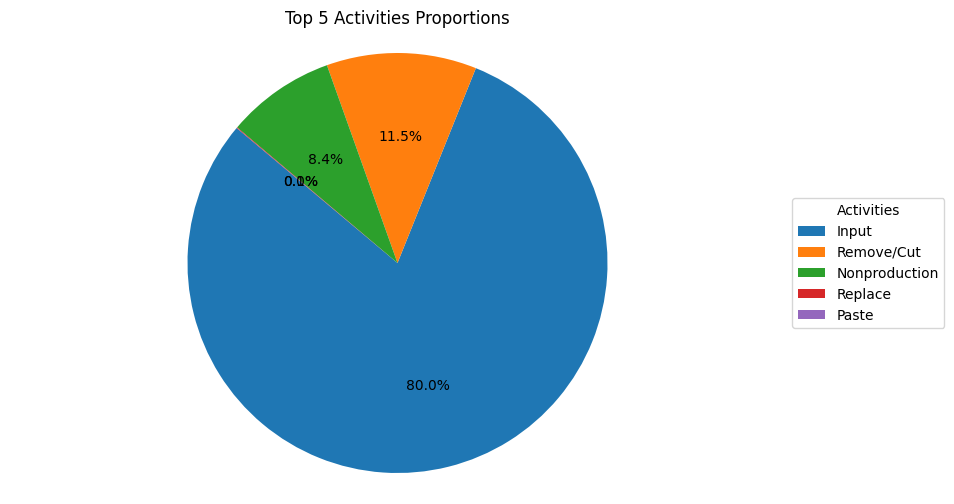

In [ ]:
plt.figure(figsize=(10, 6))
pie_wedges = plt.pie(relative_propotions, autopct='%1.1f%%', startangle=140)
plt.title('Top 5 Activities Proportions')
plt.legend(pie_wedges[0], relative_propotions.index, title="Activities", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

### Down Time - time the key or mouse button was pressed (in milliseconds)

In [ ]:
with pd.option_context('display.max_rows', None):
    display(df['down_event'].value_counts())

down_event
q                     5365319
Space                 1207128
Backspace              964089
Shift                  334227
ArrowRight             121338
Leftclick               91126
ArrowLeft               63217
.                       59586
,                       46806
ArrowDown               30874
ArrowUp                 28189
Enter                   22689
CapsLock                12568
'                       11170
Delete                  10965
Unidentified             6151
Control                  4885
"                        4102
-                        3843
?                        3155
;                        1785
=                        1155
Tab                      1081
/                         874
Rightclick                655
:                         634
(                         611
)                         578
\                         554
ContextMenu               552
End                       547
!                         546
Meta                      479

### Up Event - name of the event when a key/mouse button is released

In [ ]:
with pd.option_context('display.max_rows', None):
    display(df['up_event'].value_counts())

up_event
q                     5364789
Space                 1207128
Backspace              964089
Shift                  334227
ArrowRight             121338
Leftclick               91126
ArrowLeft               63217
.                       59586
,                       46806
ArrowDown               30874
ArrowUp                 28189
Enter                   22689
CapsLock                12568
'                       11170
Delete                  10965
Unidentified             6151
Control                  4885
"                        4102
-                        3843
?                        3155
;                        1785
=                        1155
Tab                      1081
/                         874
Rightclick                655
:                         634
(                         611
)                         578
\                         554
ContextMenu               552
End                       547
!                         546
Meta                      479
A

### Text Change - exact change made to the text

In [ ]:
df_text_changes = df['text_change'].value_counts()
df_text_changes[:60]

text_change
q                   6128208
                    1376829
NoChange             703851
.                     67797
,                     54797
\n                    27977
'                     13192
"                      4659
-                      4492
?                      3507
;                      2905
=                      2288
/                      1354
\                      1100
:                       813
(                       733
[                       725
)                       660
!                       639
q => q                  238
qqqq => q               205
qqq => q                191
>                       177
qqqqqq => q             165
]                       157
qq => q                 155
qqqqq => q              142
.                       137
qqq  => q               130
qqqq  => q              120
qqqqqqq => q            114
$                       112
*                       108
qqq                      90
qqqqq  => q              88
qqq     

In [ ]:
text_lens = [len(s) for s in df_text_changes.keys()]

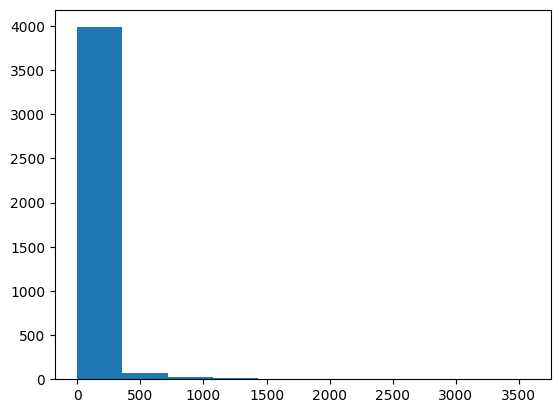

In [ ]:
plt.hist(text_lens)
plt.show()

In [ ]:
df_text_changes.tail()

text_change
q qq qqqqqqq qqqq  => q                 1
qqqqqqqqq qqqqqqq qqq qqqqqqqqq qqqq    1
 qqqqqqqqqqqqq                          1
qqqqqqq qqqqqq  => q                    1
 qqq qqqqq  =>                          1
Name: count, dtype: int64

In [ ]:
df['text len'] = [len(s) for s in df['text_change']]

In [ ]:
df.sort_values('text len', ascending=False).head(20)

,id,event_id,down_time,up_time,action_time,activity,down_event,up_event,text_change,cursor_position,word_count,text len
5978378,b8a857fc,7463,1448580,1449215,635,Remove/Cut,x,x,\nqqqqq qqq q qqqq qqq qq qqqq. q qqq qqqq qq ...,1944,355,3575
5977892,b8a857fc,6977,1331231,1331515,284,Paste,v,v,\nqqqqq qqq q qqqq qqq qq qqqq. q qqq qqqq qq ...,5206,1003,3262
5977752,b8a857fc,6837,1112736,1113224,488,Remove/Cut,x,x,\nqqqqq qqq q qqqq qqq qq qqqq. q qqq qqqq qq ...,1943,355,3262
1288929,27027716,3483,1405424,1405534,110,Replace,v,v,qqqqq qqqqq qq qqqq qqqq qqqqqq qqqqqq qqq qq ...,1563,383,3035
1568608,30235dd1,5330,1648272,1648272,0,Remove/Cut,x,x,qqqq qqq qqqq qqqq qq q qqqq? qq qqqqq qqqq q ...,0,0,2910
1568609,30235dd1,5331,1648671,1648671,0,Paste,v,v,qqqq qqq qqqq qqqq qq q qqqq? qq qqqqq qqqq q ...,2910,499,2910
1835218,3977377a,2226,1551248,1551327,79,Replace,V,V,qq qqqqqqq qqqqq qqqq qq qqqq qqqq qqqqqq qqqq...,1219,214,2464
4638614,9034ff83,2771,617870,617989,119,Remove/Cut,x,x,qqqqqqqqq qqqqqqqqq qq qqq qqqqqq qqqq qqq qqq...,0,0,2438
4638646,9034ff83,2803,623421,623519,98,Paste,v,v,qqqqqqqqq qqqqqqqqq qq qqq qqqqqq qqqq qqq qqq...,2438,405,2438
7583131,e7fe6607,4281,1704145,1704220,75,Remove/Cut,x,x,q qqqq qq qqq qqqqqqq qqqqqqqqqq qq q qqqqqqqq...,446,71,2356


### Word Count - cumulative number of words in the essay

In [ ]:
max_word_count_by_id = df.groupby('id')['word_count'].max().reset_index()
max_word_count_by_id.sort_values('word_count').head(20)

,id,word_count
851,5a3f0d07,35
1416,95acfe17,67
84,08e3c7ae,72
1355,8ee8c46c,73
344,23022dee,108
1156,79ee2112,111
545,3a266257,111
1908,c9a405c8,119
2298,eef796e6,126
166,118107cc,140


In [ ]:
max_word_count_by_id.describe()

,word_count
count,2471.000000
mean,389.966410
std,172.455317
min,35.000000
25%,255.000000
50%,351.000000
75%,480.000000
max,1326.000000


In [ ]:
max_word_count_by_id.describe()

,word_count
count,2471.000000
mean,389.966410
std,172.455317
min,35.000000
25%,255.000000
50%,351.000000
75%,480.000000
max,1326.000000


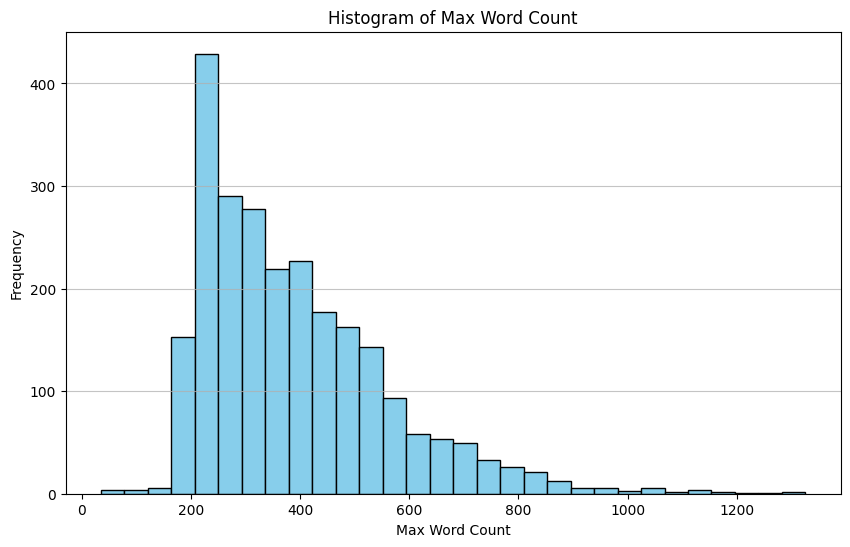

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(max_word_count_by_id['word_count'], bins=30 , color='skyblue', edgecolor='black')
plt.xlabel('Max Word Count')
plt.ylabel('Frequency')
plt.title('Histogram of Max Word Count')
plt.grid(axis='y', alpha=0.75)
plt.show()

### Outliers
* Establishing with the business
* Percentile e.g. the 5% smallest values
* A specific number, e.g., the 5 samlles Values

Summary:
Action Time - Very long duration
Very short essays
Very long text changes

### Relationships Between Features

In [ ]:
(df['action_time'] == df['up_time'] - df['down_time']).all()

np.True_

In [ ]:
(df['down_event'] == df['up_event']).mean()

np.float64(0.999936473176334)

In [ ]:
(df['down_event'] != df['up_event']).sum()

np.int64(534)

### Merging Tables

In [ ]:
set(test_df['id']).intersection(df['id'])

set()

In [ ]:
df_scores

,id,score
0,001519c8,3.5
1,0022f953,3.5
2,0042269b,6.0
3,0059420b,2.0
4,0075873a,4.0
...,...,...
2466,ffb8c745,3.5
2467,ffbef7e5,4.0
2468,ffccd6fd,1.5
2469,ffec5b38,5.0


In [ ]:
df_scores[df_scores['id'].isin(df['id'])]

,id,score
0,001519c8,3.5
1,0022f953,3.5
2,0042269b,6.0
3,0059420b,2.0
4,0075873a,4.0
...,...,...
2466,ffb8c745,3.5
2467,ffbef7e5,4.0
2468,ffccd6fd,1.5
2469,ffec5b38,5.0


### Consistency of Information Between Tables

In [ ]:
set(test_df.columns) == set(df.columns)

True

### Class Distribution

In [ ]:
sorted(df_scores['score'].unique())

[np.float64(0.5),
 np.float64(1.0),
 np.float64(1.5),
 np.float64(2.0),
 np.float64(2.5),
 np.float64(3.0),
 np.float64(3.5),
 np.float64(4.0),
 np.float64(4.5),
 np.float64(5.0),
 np.float64(5.5),
 np.float64(6.0)]

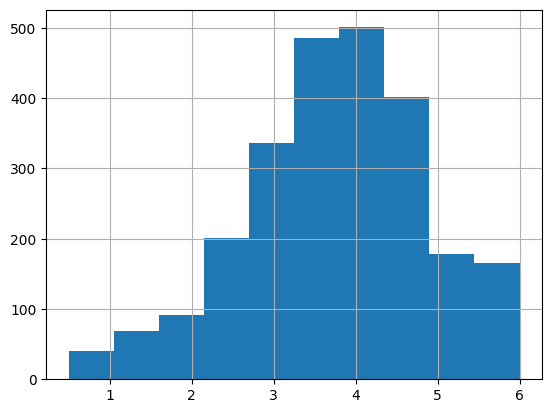

In [ ]:
df_scores['score'].hist()
plt.show()

In [ ]:
df_scores['score'].describe()

count    2471.000000
mean        3.711251
std         1.024937
min         0.500000
25%         3.000000
50%         4.000000
75%         4.500000
max         6.000000
Name: score, dtype: float64